In [1]:
import numpy as np
import pandas as pd
import os
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer


c:\Users\18820\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Load stop words


In [2]:
def load_stopwords() -> set[str]:
    stopwords = set()
    with open('../data/converted/cn_stopwords.txt', mode='r', encoding='utf-8') as stop:
        for line in stop:
            stopwords.add(line.strip())
        stop.close()
    return stopwords

stopwords = load_stopwords()

### Preprocessing

In [3]:
import re
def extract() -> list[dict]:
    # Check file structure and basic info of the dataset
    dataLink = '../data/THUCNews/THUCNews/'
    file_categories = os.listdir(dataLink)
    file_directories = []
    print(f'Categories: {file_categories}')
    for i in range(len(file_categories)):
        files_path = os.path.join(dataLink,file_categories[i]) # combine the directory, like 'data/THUCNews/THUCNews/体育, 娱乐, etc.'
        files = os.listdir(files_path)
        print(f'{file_categories[i]}: 共{len(files)}个文件{files[:5]}')
        file_directories.append(files_path)
    for i, directory in enumerate(file_directories):
        print(i, directory) # collect all directories of different categories
    
    # Traverse & Filter & Extract
    dataList = []
    regex = re.compile(r'^[\u4e00-\u9fa5]{2,4}$')   # extract Chinese characters with length within 2 and 4 only
    categories = ['Sports','Amusement','Furnishings','Lottery','Real Estate','Education']
    for j in range(len(file_directories)):
        text_length = []
        files = os.listdir(file_directories[j])
        if j in [0,1]:
            subset_len = int(len(files) * 0.75) #对于大类(体育 娱乐),取75%
        else:
            subset_len = len(files)  #其他类全取
        for k in files[:subset_len]:
            filename =os.path.join(file_directories[j],k)
            with open(filename, encoding="UTF-8", mode='r') as f:
                text = f.read()
                if(len(text) < 200): #只取长度大于200字的文本，避免后续TF-IDF产生太多空特征
                    f.close()
                    continue
                else:
                    text_length.append(len(text))
                    filtered = []
                    words = jieba.lcut(text, cut_all = False)
                    for l in words:
                        if l.strip() not in stopwords:   #remove blank
                            if regex.match(l):
                                filtered.append(l.strip())
                    dataList.append({'type': categories[j], #convert to English
                                        'filename': filename,
                                        'content': text,
                                        'segmented': ' '.join(filtered)})
                    f.close()
        print(f'{file_categories[j]} 类型下的文本,取{len(text_length)}篇,其中最长{max(text_length)}字,最短{min(text_length)}字,平均{sum(text_length) / len(text_length)}字;缺失数量{len([i for i in text_length if i == 0])}')
        subset_len = 10000
    return dataList
df = pd.DataFrame(extract())
df.iloc[::2000].to_csv('../data/converted/data.csv',encoding='utf-8-sig')
print(df.shape)
df.iloc[::8000]

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\18820\AppData\Local\Temp\jieba.cache


Categories: ['体育', '娱乐', '家居', '彩票', '房产', '教育']
体育: 共19948个文件['82044.txt', '82045.txt', '82046.txt', '82047.txt', '82048.txt']
娱乐: 共22416个文件['201820.txt', '201821.txt', '201822.txt', '201823.txt', '201824.txt']
家居: 共4690个文件['252132.txt', '252133.txt', '252134.txt', '252135.txt', '252136.txt']
彩票: 共1472个文件['262938.txt', '262939.txt', '262940.txt', '262941.txt', '262942.txt']
房产: 共4822个文件['279638.txt', '279639.txt', '279640.txt', '279641.txt', '279642.txt']
教育: 共1741个文件['290064.txt', '290065.txt', '290066.txt', '290067.txt', '290068.txt']
0 ../data/THUCNews/THUCNews/体育
1 ../data/THUCNews/THUCNews/娱乐
2 ../data/THUCNews/THUCNews/家居
3 ../data/THUCNews/THUCNews/彩票
4 ../data/THUCNews/THUCNews/房产
5 ../data/THUCNews/THUCNews/教育


Loading model cost 0.398 seconds.
Prefix dict has been built successfully.


体育 类型下的文本,取14582篇,其中最长10522字,最短200字,平均1037.306405157043字;缺失数量0
娱乐 类型下的文本,取16197篇,其中最长12778字,最短200字,平均1022.286719762919字;缺失数量0
家居 类型下的文本,取3989篇,其中最长26092字,最短201字,平均1125.8302832790173字;缺失数量0
彩票 类型下的文本,取1335篇,其中最长9046字,最短202字,平均1346.7280898876404字;缺失数量0
房产 类型下的文本,取4740篇,其中最长8485字,最短203字,平均805.5962025316455字;缺失数量0
教育 类型下的文本,取1585篇,其中最长24297字,最短200字,平均1412.7312302839116字;缺失数量0
(42428, 4)


,type,filename,content,segmented
0,Sports,../data/THUCNews/THUCNews/体育\82044.txt,孙悦全景扫描封盖2米06悍将堪称经典 三分出手未果\n 新浪体育讯 北京时间1月8日，湖人...,孙悦 全景 扫描 封盖 悍将 堪称 经典 三分 出手 未果 新浪 体育讯 北京 时间 湖人队...
8000,Sports,../data/THUCNews/THUCNews/体育\89452.txt,科比赴休城拜师大梦 奥拉朱旺：他最适合梦幻脚步\n 灰熊队的新秀中锋塔比特个子很高，身体素...,科比 休城 拜师 奥拉朱旺 适合 梦幻 脚步 灰熊队 新秀 中锋 比特 个子 身体素质 不错...
16000,Amusement,../data/THUCNews/THUCNews/娱乐\203279.txt,全民新偶像“顺溜”开播 强强联合受好评(图)\n\n 本报记者 陈明辉\n “我的兄弟叫...,全民 偶像 顺溜 开播 强强联合 好评 本报记者 陈明辉 兄弟 顺溜 参军 干下 几件 惊天...
24000,Amusement,../data/THUCNews/THUCNews/娱乐\211396.txt,《主妇》月底开播 《NY重案组》女星入住紫藤巷\n 新浪娱乐讯 紫藤巷的故事又将开始。《绝...,主妇 月底 开播 重案 女星 入住 紫藤 新浪 娱乐 紫藤 故事 绝望 主妇 新季 迎来 性...
32000,Furnishings,../data/THUCNews/THUCNews/家居\253576.txt,北美枫情实木复合地板金斯顿防污测试\n 为了营造仿古特色，该地板的表面特制了小划痕等特殊工...,北美 枫情 实木 复合地板 金斯顿 防污 测试 营造 仿古 特色 地板 表面 特制 划痕 特...
40000,Real Estate,../data/THUCNews/THUCNews/房产\283567.txt,“天使的翅膀，感恩麒麟社”亲子化妆派对招募\n 繁忙的工作是不是让您经常忽略自己可爱的宝宝...,天使 翅膀 感恩 麒麟 亲子 化妆 派对 招募 繁忙 工作 是不是 经常 忽略 可爱 宝宝 ...


### Get TF-IDF vector matrix

In [4]:
def getAllTFIDF(dataFrame, max_features, min_df, max_df):
    TFIDF = []
    def vectorize(corpus: list[str], max_features, min_df, max_df):
        vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df,
            max_df=max_df
        )
        X = vectorizer.fit_transform(corpus)
        print(f"特征词表: {vectorizer.get_feature_names_out()[::100]}")
        return X
    word_strings = dataFrame['segmented'].tolist()
    TFIDF = vectorize(word_strings, max_features, min_df, max_df)
    print(f"向量化后的shape: {TFIDF.shape}")
    print(f'总文档数{TFIDF.shape[0]}, 共提取{TFIDF.shape[1]}个特征词')
    X_dense = TFIDF.toarray() #稀疏情况统计
    zero_per_doc = (X_dense == 0).sum(axis=1) 
    print(f"每篇文档平均有 {zero_per_doc.mean():.1f} 个特征词为0")
    print(f"最稀疏的文档: {zero_per_doc.max()} 个0")
    print(f"最密集的文档: {zero_per_doc.min()} 个0")
    return TFIDF

# X = getAllTFIDF(df, 2000, 3, 0.85)

### PCA visualization

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

def vis(X):
    types = df['type'].values
    le = LabelEncoder()
    colors = le.fit_transform(types)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    print("降维后shape: ", X_pca.shape)
    
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8, c=colors, cmap='Set2')
    cbar = plt.colorbar(scatter, ticks=range(len(le.classes_)))
    cbar.ax.set_yticklabels(le.classes_)
    plt.title("PCA visualization after dimensionality reduction")
    plt.show()

# vis(X)

### K-means Clustering--Find the best K

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

# 1. 跑 K-means
#
def Kmeans(X, max_iter):
    # 存储结果
    sse_list = []      # 簇内误差平方和
    silhouette_list = []  # 轮廓系数
    k_range = range(3, 14) #测试的K范围
    
    print("开始测试不同 K 值...")
    for k in k_range:
        print(f"正在运行 K={k} ...", end=" ")
        
        # 创建 K-means 模型
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',    # 作业要求的初始化方法
            n_init=10,           # 运行10次取最优
            random_state=43,     # 固定随机种子
            max_iter=max_iter
        )
        
        # 训练
        kmeans.fit(X)
        
        # 记录 SSE（簇内误差平方和）
        sse_list.append(kmeans.inertia_)
        
        # 记录轮廓系数
        sil_score = silhouette_score(X, kmeans.labels_)
        silhouette_list.append(sil_score)
        
        print(f"SSE={kmeans.inertia_:.0f}, Silhouette={sil_score:.4f}")
    
    print("\n所有 K 值测试完成！")
    
    
    # 2. 查看结果并选最佳 K
    
    print("\n=== 各 K 值结果 ===")
    print("K\tSSE\t\t轮廓系数")
    print("-" * 40)
    for i, k in enumerate(k_range):
        print(f"{k}\t{sse_list[i]:.0f}\t\t{silhouette_list[i]:.4f}")
    
    # 找出轮廓系数最高的 K
    best_k = k_range[np.argmax(silhouette_list)]
    print(f"\n轮廓系数最高的 K 值: {best_k}")
    
    # 3. 用最佳 K 值运行最终聚类
    
    print(f"\n用 K={best_k} 运行最终聚类...")
    
    final_kmeans = KMeans(
        n_clusters=best_k,
        init='k-means++',
        n_init=10,
        random_state=43,
        max_iter=max_iter
    )
    
    #记录每篇文本所属的簇，长度为文本数量，值为k_range
    cluster_labels: list[int] = final_kmeans.fit_predict(X)
    
    print(f"每个簇的文档数量:")
    print(pd.Series(cluster_labels).value_counts().sort_index())
    return k_range, best_k, sse_list, silhouette_list, cluster_labels

# k_range, best_k, sse_list, silhouette_list, cluster_labels = Kmeans(X, 300)


### Analysis based on the best result

In [7]:
# 4. 计算评估指标
# 真实标签
def analysis(X, best_k, cluster_labels):
    true_labels = df['type'].tolist()
    
    # 4.1 轮廓系数
    sil_score_final = silhouette_score(X, cluster_labels)
    print(f"\n=== 评估指标 ===")
    print(f"轮廓系数 (Silhouette Score): {sil_score_final:.4f}")
    
    # 4.2 NMI（归一化互信息）
    nmi_score = normalized_mutual_info_score(true_labels, cluster_labels)
    print(f"NMI (归一化互信息): {nmi_score:.4f}")
    
    # 4.3 纯度 (Purity)
    # 计算方式:遍历每个簇,把每个簇中占有最多数量的文本类型视为该簇的类型
    purity = 0
    for cluster_id in range(best_k): #遍历所有簇
        #当cluster为i, 返回一个长度为len(cluster_labels)的bool list给mask,只有labels[k] == i, labels[k] = True;
        mask: list[bool] = (cluster_labels == cluster_id)  
        if mask.sum() == 0:          #mask.sum()返回所有True的个数,即当簇内的文档数
            continue                 
        # 统计该簇中各类别的数量
        cluster_types = pd.Series(true_labels)[mask]
        max_count = cluster_types.value_counts().max()
        purity += max_count
    
    purity = purity / len(cluster_labels)
    print(f"纯度 (Purity): {purity:.4f}")
    
    # 5. 查看每个簇的真实类别分布（理解聚类结果）
    
    print("\n=== 每个簇的真实类别分布 ===")
    for cluster_id in range(best_k):
        mask = (cluster_labels == cluster_id)
        cluster_types = pd.Series(true_labels)[mask]
        top1_label = cluster_types.value_counts().index[0]
        print(f"\n簇 {cluster_id, top1_label} (共 {mask.sum()} 篇文档):")
        # print(cluster_types.value_counts().head(3))  # 显示前3个最多的类别
        top3 = cluster_types.value_counts().head(3)
        for i in range(3):
            try:
                print(f"{top3.index[i]},  {top3.iloc[i]},  {(top3.iloc[i] / top3.sum()):.2%}")
            except:
                break
    return sil_score_final, purity, nmi_score
# analysis(X, best_k, cluster_labels)
    

### Figures: Elbow of SSE & Silhouette Coeffient

In [8]:
# ============================================
# 6. 画出肘部图
# ============================================
def figures(k_range, sse_list,silhouette_list):
    plt.figure(figsize=(12, 5))
    
    # 子图1：肘部图（SSE）
    plt.subplot(1, 2, 1)
    plt.plot(k_range, sse_list, 'bo-')
    plt.xlabel('K value')
    plt.ylabel('SSE ')
    plt.title('elbow of SSE')
    plt.grid(True)
    
    # 子图2：轮廓系数图
    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouette_list, 'ro-')
    plt.xlabel('K value')
    plt.ylabel('silhouette')
    plt.title('silhouette coef')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
# figures(k_range, sse_list, silhouette_list)

In [ ]:
def control_variables(method):
    results = []
    if(method == 'vectorization'):    #针对向量化参数作控制变量实验
        def pipeline(dataFrame, max_feat,min_df,max_df):
            X = getAllTFIDF(dataFrame, max_feat, min_df, max_df)
            vis(X)
            k_range, best_k, sse_list, silhouette_list, cluster_labels = Kmeans(X,300)
            figures(k_range, sse_list, silhouette_list)
            return analysis(X, best_k, cluster_labels)
        params = [[1000, 2, 0.7], [2000,3,0.85],[5000,10,0.7],[8000,20,0.65]]
        for i in params:
            print("="*50)
            print(f"在向量化参数组{params.index(i) + 1}: {i}下运行")
            results.append(pipeline(df, i[0],i[1],i[2]))
    else:       #针对Kmeans最大迭代次数作控制变量实验
        def pipeline(dataFrame, max_iter):
            X = getAllTFIDF(dataFrame, 2000, 3, 0.85)
            k_range, best_k, sse_list, silhouette_list, cluster_labels = Kmeans(X,max_iter)
            figures(k_range, sse_list, silhouette_list)
            return analysis(X, best_k, cluster_labels)
        params = [20, 50, 80, 100]
        for i in params:
            print("="*50)
            print(f"在Kmeans最大迭代次数={i}下运行")
            results.append(pipeline(df, i))
    
    silhouette = [r[0] for r in results]  
    purity = [r[1] for r in results]      
    nmi = [r[2] for r in results]         

    # 画图
    schemes = [f'Param 1: {params[0]}', f'Param 2: {params[1]}', f'Param 3: {params[2]}',f'Param 4: {params[3]}']
    x = np.arange(len(schemes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(x - width, silhouette, width, label='Silhouette', color='steelblue')
    ax.bar(x, purity, width, label='Purity', color='coral')
    ax.bar(x + width, nmi, width, label='NMI', color='seagreen')

    ax.set_xlabel('Parameters')
    ax.set_ylabel('Values')
    ax.set_title('Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(schemes)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.show()


在向量化参数组1: [1000, 2, 0.7]下运行
特征词表: ['一下' '交通' '准备' '商业' '尼克斯' '房产' '最大' '环境' '缺席' '身高']
向量化后的shape: (42428, 1000)
总文档数42428, 共提取1000个特征词
每篇文档平均有 930.9 个特征词为0
最稀疏的文档: 1000 个0
最密集的文档: 581 个0
降维后shape:  (42428, 2)


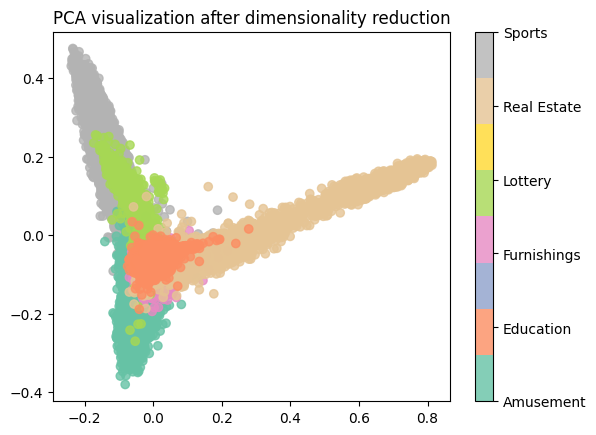

开始测试不同 K 值...
正在运行 K=3 ... SSE=37733, Silhouette=0.0448
正在运行 K=4 ... SSE=37179, Silhouette=0.0464
正在运行 K=5 ... SSE=36708, Silhouette=0.0411
正在运行 K=6 ... SSE=36293, Silhouette=0.0450
正在运行 K=7 ... SSE=35897, Silhouette=0.0492
正在运行 K=8 ... SSE=35548, Silhouette=0.0535
正在运行 K=9 ... SSE=35292, Silhouette=0.0553
正在运行 K=10 ... SSE=35043, Silhouette=0.0570
正在运行 K=11 ... SSE=34846, Silhouette=0.0577
正在运行 K=12 ... SSE=34644, Silhouette=0.0564
正在运行 K=13 ... SSE=34452, Silhouette=0.0537

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
3	37733		0.0448
4	37179		0.0464
5	36708		0.0411
6	36293		0.0450
7	35897		0.0492
8	35548		0.0535
9	35292		0.0553
10	35043		0.0570
11	34846		0.0577
12	34644		0.0564
13	34452		0.0537

轮廓系数最高的 K 值: 11

用 K=11 运行最终聚类...
每个簇的文档数量:
0     1175
1     3291
2     7032
3     1883
4     3716
5     1549
6     2888
7     6415
8     4989
9     7287
10    2203
Name: count, dtype: int64


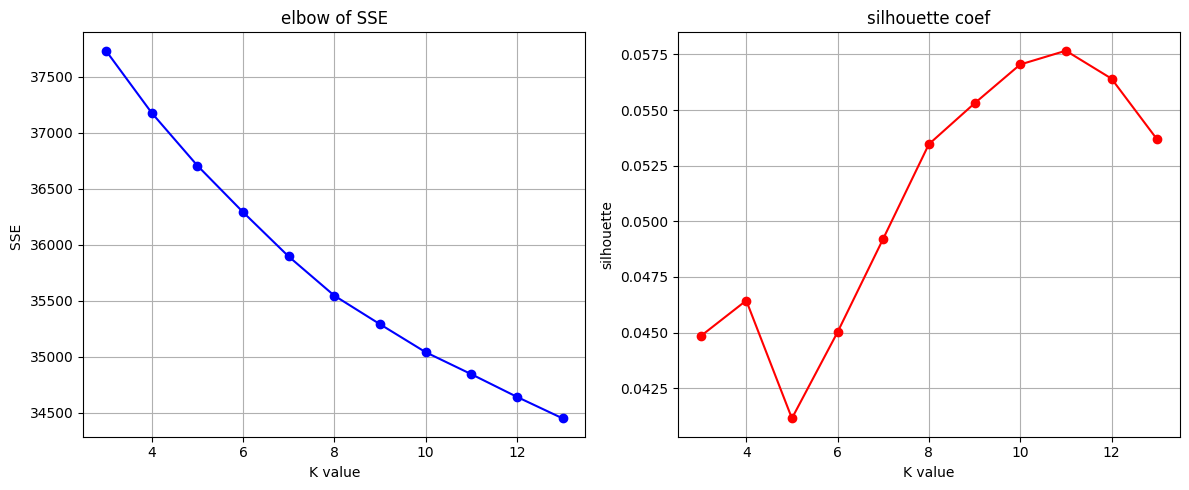


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0577
NMI (归一化互信息): 0.5935
纯度 (Purity): 0.8863

=== 每个簇的真实类别分布 ===

簇 (0, 'Education') (共 1175 篇文档):
Education,  1173,  99.83%
Amusement,  2,  0.17%

簇 (1, 'Sports') (共 3291 篇文档):
Sports,  3290,  99.97%
Amusement,  1,  0.03%

簇 (2, 'Amusement') (共 7032 篇文档):
Amusement,  4200,  72.70%
Lottery,  811,  14.04%
Sports,  766,  13.26%

簇 (3, 'Amusement') (共 1883 篇文档):
Amusement,  1878,  99.73%
Sports,  4,  0.21%
Real Estate,  1,  0.05%

簇 (4, 'Amusement') (共 3716 篇文档):
Amusement,  3702,  99.70%
Sports,  7,  0.19%
Real Estate,  4,  0.11%

簇 (5, 'Sports') (共 1549 篇文档):
Sports,  1548,  99.94%
Real Estate,  1,  0.06%

簇 (6, 'Real Estate') (共 2888 篇文档):
Real Estate,  2888,  100.00%

簇 (7, 'Amusement') (共 6415 篇文档):
Amusement,  6401,  99.81%
Real Estate,  7,  0.11%
Lottery,  5,  0.08%

簇 (8, 'Furnishings') (共 4989 篇文档):
Furnishings,  3557,  71.45%
Real Estate,  1408,  28.28%
Education,  13,  0.26%

簇 (9, 'Sports') (共 7287 篇文档):
Sports,  6762,  92.85%
Lottery,

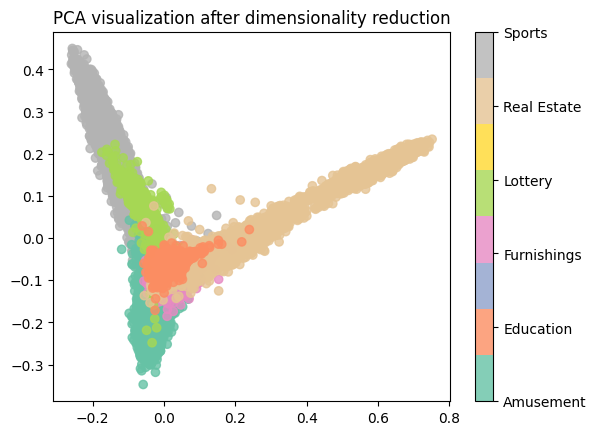

开始测试不同 K 值...
正在运行 K=3 ... SSE=38738, Silhouette=0.0342
正在运行 K=4 ... SSE=38318, Silhouette=0.0355
正在运行 K=5 ... SSE=37924, Silhouette=0.0308
正在运行 K=6 ... SSE=37596, Silhouette=0.0343
正在运行 K=7 ... SSE=37271, Silhouette=0.0371
正在运行 K=8 ... SSE=37063, Silhouette=0.0394
正在运行 K=9 ... SSE=36780, Silhouette=0.0418
正在运行 K=10 ... SSE=36601, Silhouette=0.0428
正在运行 K=11 ... SSE=36452, Silhouette=0.0436
正在运行 K=12 ... SSE=36287, Silhouette=0.0428
正在运行 K=13 ... SSE=36123, Silhouette=0.0448

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
3	38738		0.0342
4	38318		0.0355
5	37924		0.0308
6	37596		0.0343
7	37271		0.0371
8	37063		0.0394
9	36780		0.0418
10	36601		0.0428
11	36452		0.0436
12	36287		0.0428
13	36123		0.0448

轮廓系数最高的 K 值: 13

用 K=13 运行最终聚类...
每个簇的文档数量:
0     6536
1     2881
2     7368
3     6739
4     3321
5     1509
6     1396
7     2878
8     1180
9     4558
10    2518
11     680
12     864
Name: count, dtype: int64


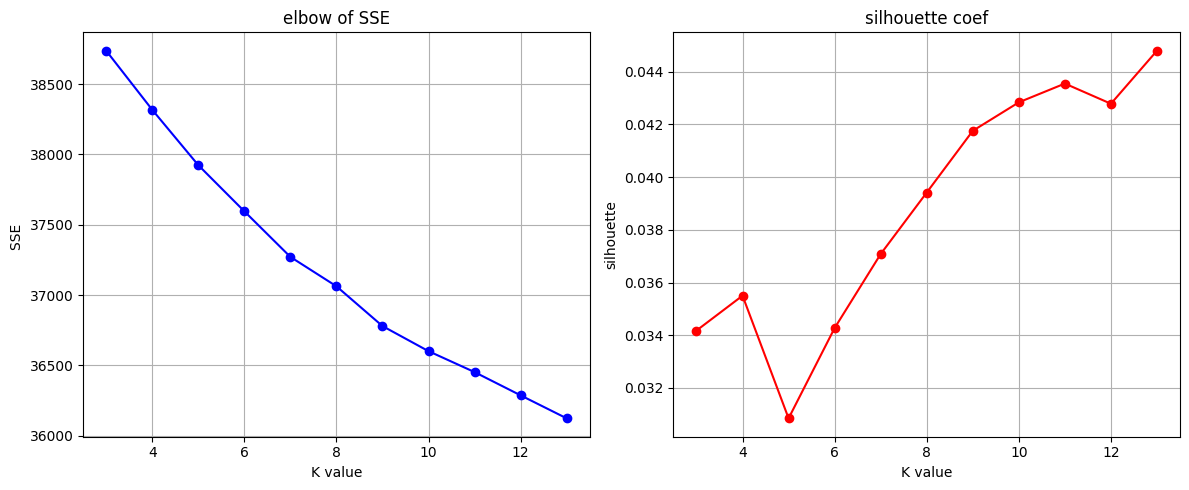


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0448
NMI (归一化互信息): 0.6079
纯度 (Purity): 0.8901

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6536 篇文档):
Amusement,  2412,  44.94%
Real Estate,  1813,  33.78%
Furnishings,  1142,  21.28%

簇 (1, 'Real Estate') (共 2881 篇文档):
Real Estate,  2881,  100.00%

簇 (2, 'Sports') (共 7368 篇文档):
Sports,  6911,  93.84%
Lottery,  448,  6.08%
Amusement,  6,  0.08%

簇 (3, 'Amusement') (共 6739 篇文档):
Amusement,  6725,  99.85%
Lottery,  5,  0.07%
Real Estate,  5,  0.07%

簇 (4, 'Sports') (共 3321 篇文档):
Sports,  3320,  99.97%
Amusement,  1,  0.03%

簇 (5, 'Sports') (共 1509 篇文档):
Sports,  1508,  99.93%
Real Estate,  1,  0.07%

簇 (6, 'Sports') (共 1396 篇文档):
Sports,  1396,  100.00%

簇 (7, 'Furnishings') (共 2878 篇文档):
Furnishings,  2842,  98.82%
Real Estate,  32,  1.11%
Amusement,  2,  0.07%

簇 (8, 'Education') (共 1180 篇文档):
Education,  1179,  99.92%
Amusement,  1,  0.08%

簇 (9, 'Amusement') (共 4558 篇文档):
Amusement,  4544,  99.78%
Sports,  7,  0.15%
Furnishings,  3,  0.07%

簇 (1

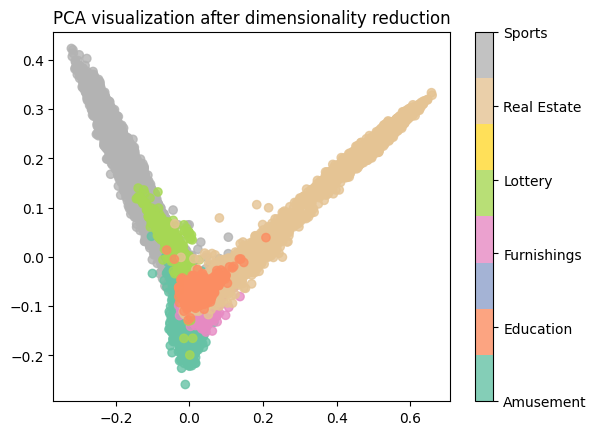

开始测试不同 K 值...
正在运行 K=3 ... SSE=39737, Silhouette=0.0244
正在运行 K=4 ... SSE=39412, Silhouette=0.0200
正在运行 K=5 ... SSE=39148, Silhouette=0.0228
正在运行 K=6 ... SSE=38902, Silhouette=0.0245
正在运行 K=7 ... SSE=38664, Silhouette=0.0263
正在运行 K=8 ... SSE=38444, Silhouette=0.0290
正在运行 K=9 ... SSE=38275, Silhouette=0.0297
正在运行 K=10 ... SSE=38144, Silhouette=0.0304
正在运行 K=11 ... SSE=38001, Silhouette=0.0320
正在运行 K=12 ... SSE=37896, Silhouette=0.0294
正在运行 K=13 ... SSE=37762, Silhouette=0.0317

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
3	39737		0.0244
4	39412		0.0200
5	39148		0.0228
6	38902		0.0245
7	38664		0.0263
8	38444		0.0290
9	38275		0.0297
10	38144		0.0304
11	38001		0.0320
12	37896		0.0294
13	37762		0.0317

轮廓系数最高的 K 值: 11

用 K=11 运行最终聚类...
每个簇的文档数量:
0     1190
1     1480
2     2874
3     7896
4     6498
5     3321
6     7352
7     5150
8      679
9     3826
10    2162
Name: count, dtype: int64


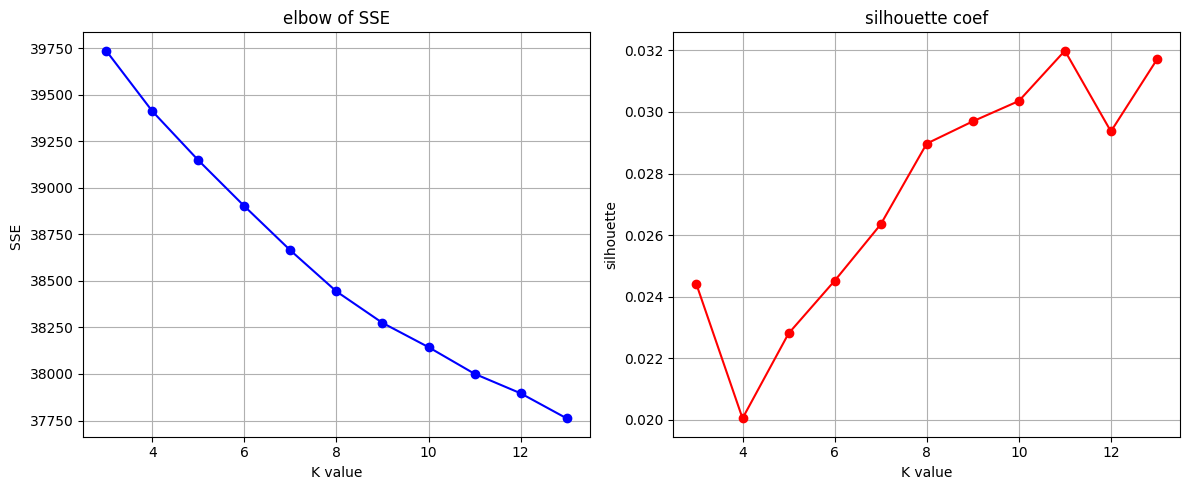


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0320
NMI (归一化互信息): 0.6237
纯度 (Purity): 0.9063

=== 每个簇的真实类别分布 ===

簇 (0, 'Education') (共 1190 篇文档):
Education,  1190,  100.00%

簇 (1, 'Sports') (共 1480 篇文档):
Sports,  1479,  99.93%
Real Estate,  1,  0.07%

簇 (2, 'Real Estate') (共 2874 篇文档):
Real Estate,  2874,  100.00%

簇 (3, 'Amusement') (共 7896 篇文档):
Amusement,  5890,  84.74%
Sports,  679,  9.77%
Education,  382,  5.50%

簇 (4, 'Amusement') (共 6498 篇文档):
Amusement,  6479,  99.78%
Real Estate,  9,  0.14%
Lottery,  5,  0.08%

簇 (5, 'Sports') (共 3321 篇文档):
Sports,  3320,  99.97%
Amusement,  1,  0.03%

簇 (6, 'Sports') (共 7352 篇文档):
Sports,  6930,  94.27%
Lottery,  419,  5.70%
Real Estate,  2,  0.03%

簇 (7, 'Furnishings') (共 5150 篇文档):
Furnishings,  3639,  70.92%
Real Estate,  1476,  28.77%
Amusement,  16,  0.31%

簇 (8, 'Lottery') (共 679 篇文档):
Lottery,  678,  99.85%
Real Estate,  1,  0.15%

簇 (9, 'Amusement') (共 3826 篇文档):
Amusement,  3811,  99.69%
Sports,  7,  0.18%
Real Estate,  5,  0.13%

簇 (10, 

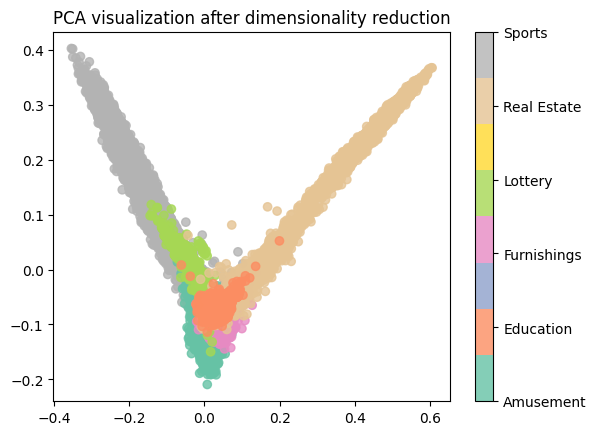

开始测试不同 K 值...
正在运行 K=3 ... SSE=40069, Silhouette=0.0212
正在运行 K=4 ... SSE=39768, Silhouette=0.0172
正在运行 K=5 ... SSE=39549, Silhouette=0.0188
正在运行 K=6 ... SSE=39306, Silhouette=0.0218
正在运行 K=7 ... SSE=39131, Silhouette=0.0227
正在运行 K=8 ... SSE=38938, Silhouette=0.0250
正在运行 K=9 ... SSE=38795, Silhouette=0.0255
正在运行 K=10 ... SSE=38665, Silhouette=0.0266
正在运行 K=11 ... SSE=38547, Silhouette=0.0252
正在运行 K=12 ... SSE=38443, Silhouette=0.0247
正在运行 K=13 ... SSE=38362, Silhouette=0.0229

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
3	40069		0.0212
4	39768		0.0172
5	39549		0.0188
6	39306		0.0218
7	39131		0.0227
8	38938		0.0250
9	38795		0.0255
10	38665		0.0266
11	38547		0.0252
12	38443		0.0247
13	38362		0.0229

轮廓系数最高的 K 值: 10

用 K=10 运行最终聚类...
每个簇的文档数量:
0    6772
1    3301
2    1189
3    7186
4    1482
5    2879
6    4401
7    3064
8    9999
9    2155
Name: count, dtype: int64


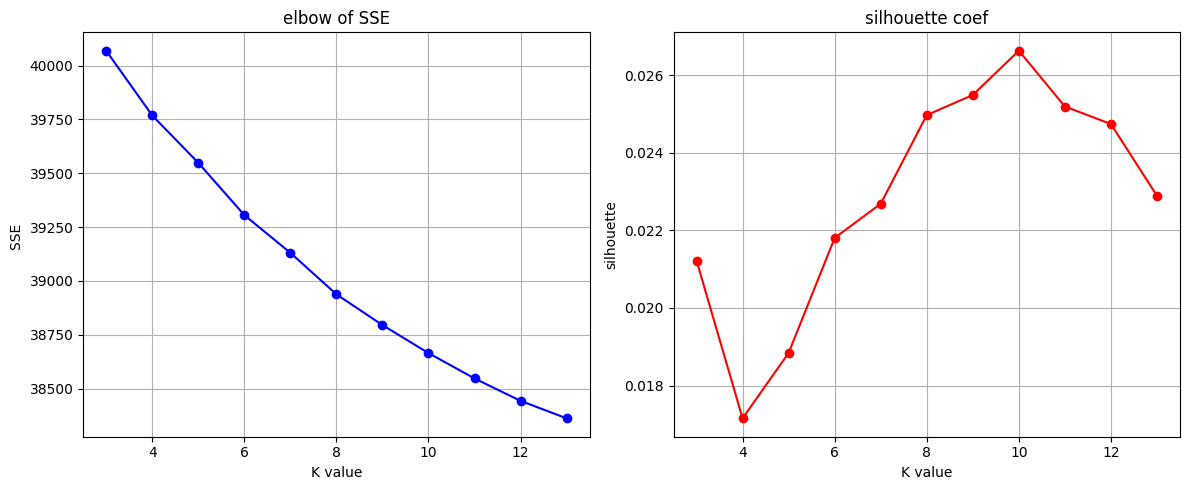


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0266
NMI (归一化互信息): 0.5910
纯度 (Purity): 0.8730

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6772 篇文档):
Amusement,  6753,  99.81%
Real Estate,  8,  0.12%
Lottery,  5,  0.07%

簇 (1, 'Sports') (共 3301 篇文档):
Sports,  3300,  99.97%
Amusement,  1,  0.03%

簇 (2, 'Education') (共 1189 篇文档):
Education,  1189,  100.00%

簇 (3, 'Sports') (共 7186 篇文档):
Sports,  6851,  95.34%
Lottery,  333,  4.63%
Real Estate,  2,  0.03%

簇 (4, 'Sports') (共 1482 篇文档):
Sports,  1481,  99.93%
Real Estate,  1,  0.07%

簇 (5, 'Real Estate') (共 2879 篇文档):
Real Estate,  2879,  100.00%

簇 (6, 'Amusement') (共 4401 篇文档):
Amusement,  4386,  99.73%
Sports,  8,  0.18%
Real Estate,  4,  0.09%

簇 (7, 'Furnishings') (共 3064 篇文档):
Furnishings,  2989,  97.62%
Real Estate,  71,  2.32%
Amusement,  2,  0.07%

簇 (8, 'Amusement') (共 9999 篇文档):
Amusement,  5055,  64.59%
Real Estate,  1775,  22.68%
Lottery,  996,  12.73%

簇 (9, 'Sports') (共 2155 篇文档):
Sports,  2155,  100.00%


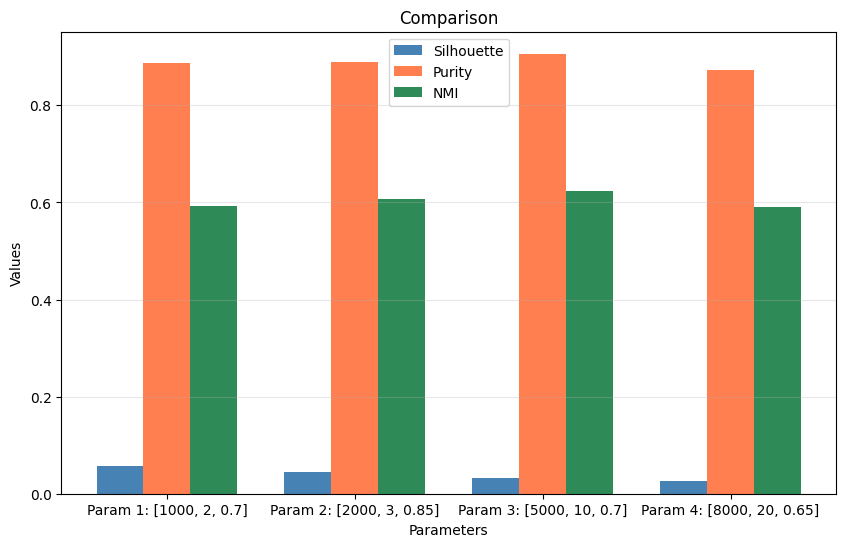

In [10]:
control_variables('vectorization')

在Kmeans最大迭代次数=20下运行
特征词表: ['一下' '不想' '交通' '做出' '利用' '取胜' '地位' '妈妈' '巴蒂尔' '很难' '手段' '教育' '有没有' '没什么'
 '现实' '突出' '网络' '规定' '轨道' '问题']
向量化后的shape: (42428, 2000)
总文档数42428, 共提取2000个特征词
每篇文档平均有 1908.3 个特征词为0
最稀疏的文档: 1999 个0
最密集的文档: 1328 个0
开始测试不同 K 值...
正在运行 K=3 ... SSE=38738, Silhouette=0.0342
正在运行 K=4 ... SSE=38318, Silhouette=0.0355
正在运行 K=5 ... SSE=37924, Silhouette=0.0308
正在运行 K=6 ... SSE=37596, Silhouette=0.0343
正在运行 K=7 ... SSE=37271, Silhouette=0.0371
正在运行 K=8 ... SSE=37065, Silhouette=0.0398
正在运行 K=9 ... SSE=36780, Silhouette=0.0419
正在运行 K=10 ... SSE=36601, Silhouette=0.0428
正在运行 K=11 ... SSE=36452, Silhouette=0.0436
正在运行 K=12 ... SSE=36314, Silhouette=0.0424
正在运行 K=13 ... SSE=36123, Silhouette=0.0448

所有 K 值测试完成！

=== 各 K 值结果 ===
K	SSE		轮廓系数
----------------------------------------
3	38738		0.0342
4	38318		0.0355
5	37924		0.0308
6	37596		0.0343
7	37271		0.0371
8	37065		0.0398
9	36780		0.0419
10	36601		0.0428
11	36452		0.0436
12	36314		0.0424
13	36123		0.0448

轮廓系数最高的 K 值: 13

用 K=

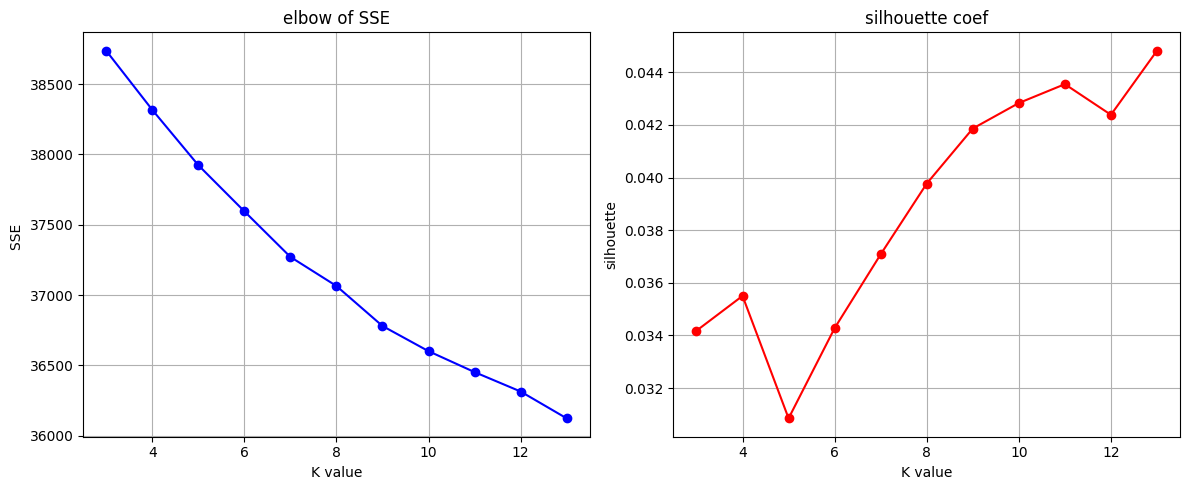


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0448
NMI (归一化互信息): 0.6061
纯度 (Purity): 0.8898

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6663 篇文档):
Amusement,  2527,  46.21%
Real Estate,  1810,  33.10%
Furnishings,  1132,  20.70%

簇 (1, 'Real Estate') (共 2881 篇文档):
Real Estate,  2881,  100.00%

簇 (2, 'Sports') (共 7330 篇文档):
Sports,  6875,  93.83%
Lottery,  447,  6.10%
Amusement,  5,  0.07%

簇 (3, 'Amusement') (共 6719 篇文档):
Amusement,  6705,  99.85%
Lottery,  5,  0.07%
Real Estate,  5,  0.07%

簇 (4, 'Sports') (共 3334 篇文档):
Sports,  3333,  99.97%
Amusement,  1,  0.03%

簇 (5, 'Sports') (共 1508 篇文档):
Sports,  1507,  99.93%
Real Estate,  1,  0.07%

簇 (6, 'Sports') (共 1396 篇文档):
Sports,  1396,  100.00%

簇 (7, 'Furnishings') (共 2890 篇文档):
Furnishings,  2852,  98.75%
Real Estate,  34,  1.18%
Amusement,  2,  0.07%

簇 (8, 'Education') (共 1180 篇文档):
Education,  1179,  99.92%
Amusement,  1,  0.08%

簇 (9, 'Amusement') (共 4484 篇文档):
Amusement,  4469,  99.75%
Sports,  7,  0.16%
Real Estate,  4,  0.09%

簇 (1

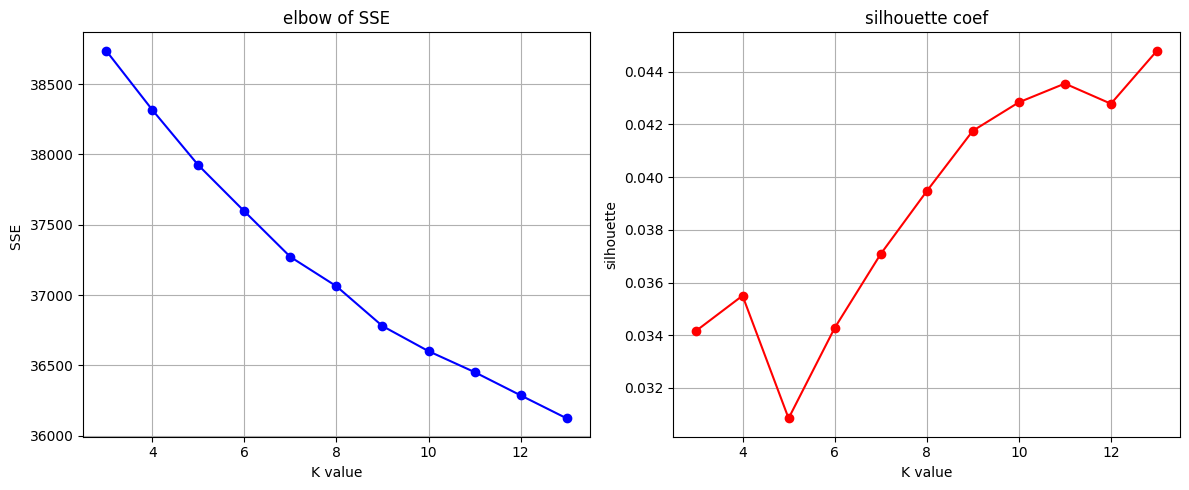


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0448
NMI (归一化互信息): 0.6079
纯度 (Purity): 0.8901

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6536 篇文档):
Amusement,  2412,  44.94%
Real Estate,  1813,  33.78%
Furnishings,  1142,  21.28%

簇 (1, 'Real Estate') (共 2881 篇文档):
Real Estate,  2881,  100.00%

簇 (2, 'Sports') (共 7368 篇文档):
Sports,  6911,  93.84%
Lottery,  448,  6.08%
Amusement,  6,  0.08%

簇 (3, 'Amusement') (共 6739 篇文档):
Amusement,  6725,  99.85%
Lottery,  5,  0.07%
Real Estate,  5,  0.07%

簇 (4, 'Sports') (共 3321 篇文档):
Sports,  3320,  99.97%
Amusement,  1,  0.03%

簇 (5, 'Sports') (共 1509 篇文档):
Sports,  1508,  99.93%
Real Estate,  1,  0.07%

簇 (6, 'Sports') (共 1396 篇文档):
Sports,  1396,  100.00%

簇 (7, 'Furnishings') (共 2878 篇文档):
Furnishings,  2842,  98.82%
Real Estate,  32,  1.11%
Amusement,  2,  0.07%

簇 (8, 'Education') (共 1180 篇文档):
Education,  1179,  99.92%
Amusement,  1,  0.08%

簇 (9, 'Amusement') (共 4558 篇文档):
Amusement,  4544,  99.78%
Sports,  7,  0.15%
Furnishings,  3,  0.07%

簇 (1

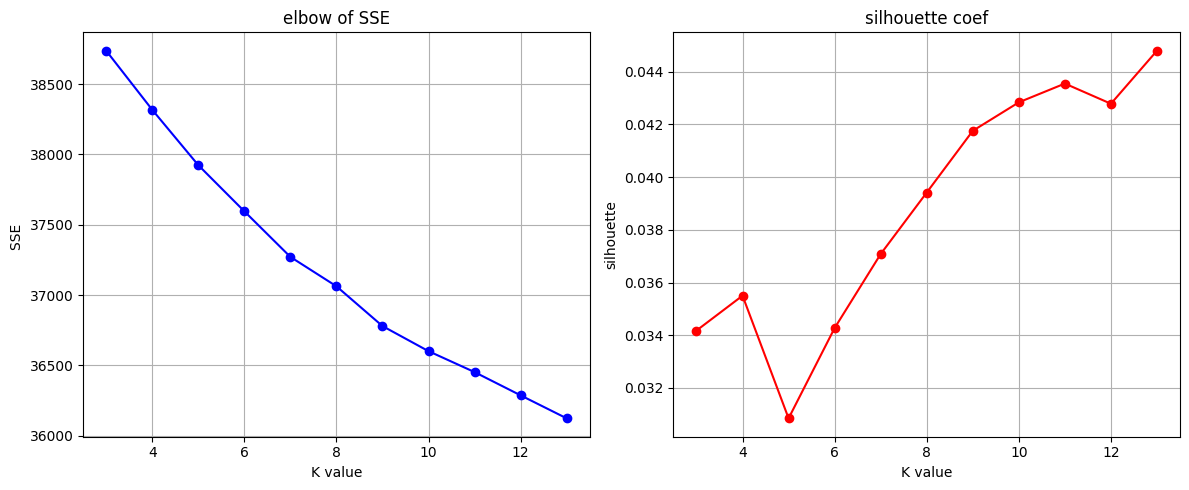


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0448
NMI (归一化互信息): 0.6079
纯度 (Purity): 0.8901

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6536 篇文档):
Amusement,  2412,  44.94%
Real Estate,  1813,  33.78%
Furnishings,  1142,  21.28%

簇 (1, 'Real Estate') (共 2881 篇文档):
Real Estate,  2881,  100.00%

簇 (2, 'Sports') (共 7368 篇文档):
Sports,  6911,  93.84%
Lottery,  448,  6.08%
Amusement,  6,  0.08%

簇 (3, 'Amusement') (共 6739 篇文档):
Amusement,  6725,  99.85%
Lottery,  5,  0.07%
Real Estate,  5,  0.07%

簇 (4, 'Sports') (共 3321 篇文档):
Sports,  3320,  99.97%
Amusement,  1,  0.03%

簇 (5, 'Sports') (共 1509 篇文档):
Sports,  1508,  99.93%
Real Estate,  1,  0.07%

簇 (6, 'Sports') (共 1396 篇文档):
Sports,  1396,  100.00%

簇 (7, 'Furnishings') (共 2878 篇文档):
Furnishings,  2842,  98.82%
Real Estate,  32,  1.11%
Amusement,  2,  0.07%

簇 (8, 'Education') (共 1180 篇文档):
Education,  1179,  99.92%
Amusement,  1,  0.08%

簇 (9, 'Amusement') (共 4558 篇文档):
Amusement,  4544,  99.78%
Sports,  7,  0.15%
Furnishings,  3,  0.07%

簇 (1

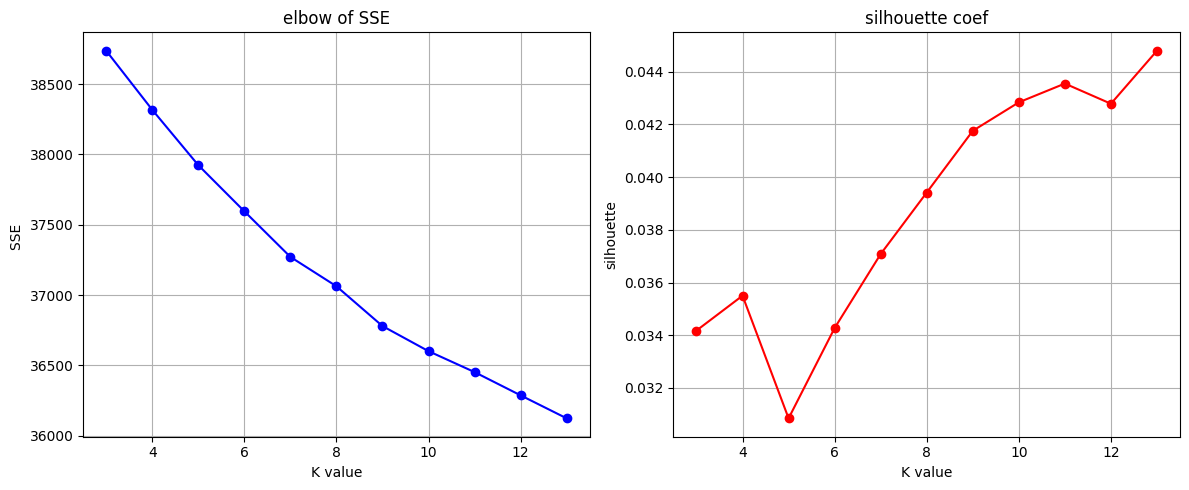


=== 评估指标 ===
轮廓系数 (Silhouette Score): 0.0448
NMI (归一化互信息): 0.6079
纯度 (Purity): 0.8901

=== 每个簇的真实类别分布 ===

簇 (0, 'Amusement') (共 6536 篇文档):
Amusement,  2412,  44.94%
Real Estate,  1813,  33.78%
Furnishings,  1142,  21.28%

簇 (1, 'Real Estate') (共 2881 篇文档):
Real Estate,  2881,  100.00%

簇 (2, 'Sports') (共 7368 篇文档):
Sports,  6911,  93.84%
Lottery,  448,  6.08%
Amusement,  6,  0.08%

簇 (3, 'Amusement') (共 6739 篇文档):
Amusement,  6725,  99.85%
Lottery,  5,  0.07%
Real Estate,  5,  0.07%

簇 (4, 'Sports') (共 3321 篇文档):
Sports,  3320,  99.97%
Amusement,  1,  0.03%

簇 (5, 'Sports') (共 1509 篇文档):
Sports,  1508,  99.93%
Real Estate,  1,  0.07%

簇 (6, 'Sports') (共 1396 篇文档):
Sports,  1396,  100.00%

簇 (7, 'Furnishings') (共 2878 篇文档):
Furnishings,  2842,  98.82%
Real Estate,  32,  1.11%
Amusement,  2,  0.07%

簇 (8, 'Education') (共 1180 篇文档):
Education,  1179,  99.92%
Amusement,  1,  0.08%

簇 (9, 'Amusement') (共 4558 篇文档):
Amusement,  4544,  99.78%
Sports,  7,  0.15%
Furnishings,  3,  0.07%

簇 (1

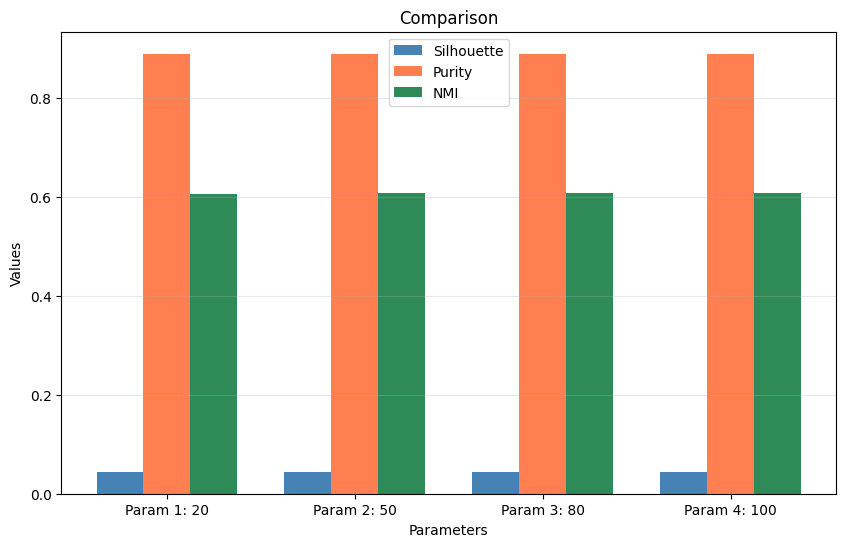

In [11]:
control_variables('kmeans')